# Proyecto Final 2 — Predicción de enfermedad cardíaca con Machine Learning

**Autora:** Mariana Martinelli  
**Tarea:** clasificación binaria  
**Objetivo:** `HeartDisease`  
**Métrica principal:** ROC-AUC  
**Métrica complementaria:** Recall de la clase positiva

Este notebook implementa un pipeline reproducible desde la carga y validación de datos hasta la selección del modelo y su explicación con SHAP. Es un proyecto educativo y no reemplaza una evaluación médica.

## 1. Formulación del problema

Se busca estimar si un paciente presenta enfermedad cardíaca (`1`) o no (`0`) a partir de variables clínicas. ROC-AUC se usa para comparar modelos y recall para vigilar falsos negativos, especialmente costosos en un escenario de detección.

## 2. Librerías y reproducibilidad

In [37]:
# Descomentar si faltan paquetes:
# %pip install -q pandas numpy matplotlib scikit-learn xgboost shap

In [38]:
from pathlib import Path
import warnings, random, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap
SEED=42
np.random.seed(SEED); random.seed(SEED); warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(8,5); plt.rcParams['axes.grid']=True
print('Python',sys.version.split()[0], '| pandas',pd.__version__)

Python 3.12.13 | pandas 2.2.2


## 3. Carga del dataset

In [39]:
paths=[Path('heart.csv'),Path('data/heart.csv'),Path('heart.csv'),Path('/mnt/data/heart.csv')]
data_path=next((p for p in paths if p.exists()),None)
if data_path is None: raise FileNotFoundError("Guardar heart.csv junto al notebook o en data/")
try: df_raw=pd.read_csv(data_path,encoding='utf-8')
except UnicodeDecodeError: df_raw=pd.read_csv(data_path,encoding='latin-1')
print('Archivo:',data_path,'| Dimensiones:',df_raw.shape)
df_raw.head()

Archivo: heart.csv | Dimensiones: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 4. Diccionario de variables

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope` y `HeartDisease`. La última es la variable objetivo.

## 5. Control de calidad

In [40]:
expected=['Age','Sex','ChestPainType','RestingBP','Cholesterol','FastingBS','RestingECG','MaxHR','ExerciseAngina','Oldpeak','ST_Slope','HeartDisease']
missing=sorted(set(expected)-set(df_raw.columns))
if missing: raise ValueError(f'Faltan columnas: {missing}')
df=df_raw[expected].copy()
pd.DataFrame({'tipo':df.dtypes.astype(str),'nulos':df.isna().sum(),'unicos':df.nunique(dropna=False)})

,tipo,nulos,unicos
Age,int64,0,50
Sex,object,0,2
ChestPainType,object,0,4
RestingBP,int64,0,67
Cholesterol,int64,0,222
FastingBS,int64,0,2
RestingECG,object,0,3
MaxHR,int64,0,119
ExerciseAngina,object,0,2
Oldpeak,float64,0,53


In [41]:
print('Duplicados:', df.duplicated().sum())
print('\nObjetivo:')
print(df.HeartDisease.value_counts())
print('\nProporciones:')
print(df.HeartDisease.value_counts(normalize=True).round(4))
print('\nCeros sospechosos:')
print((df[['RestingBP', 'Cholesterol']] == 0).sum())

Duplicados: 0

Objetivo:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Proporciones:
HeartDisease
1    0.5534
0    0.4466
Name: proportion, dtype: float64

Ceros sospechosos:
RestingBP        1
Cholesterol    172
dtype: int64


Los ceros en `RestingBP` y `Cholesterol` se consideran nulos encubiertos. Se reemplazan por `NaN` y se imputan dentro del pipeline para evitar fuga de datos.

## 6. Análisis exploratorio

In [42]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


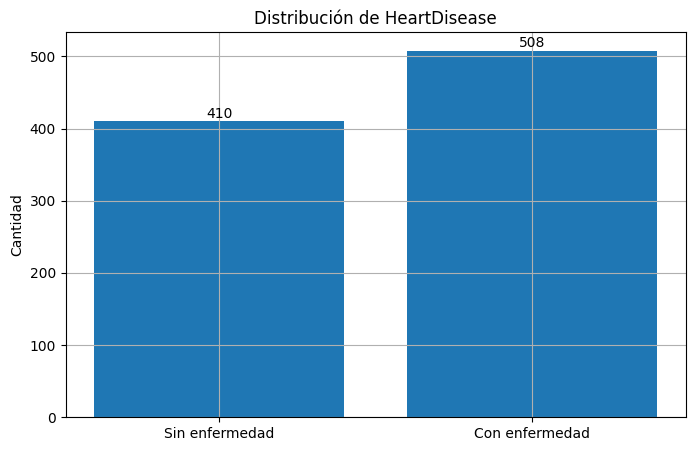

In [43]:
counts=df.HeartDisease.value_counts().sort_index()
fig,ax=plt.subplots(); ax.bar(['Sin enfermedad','Con enfermedad'],counts.values); ax.set_title('Distribución de HeartDisease'); ax.set_ylabel('Cantidad')
for i,v in enumerate(counts.values): ax.text(i,v+5,str(v),ha='center')
plt.show()

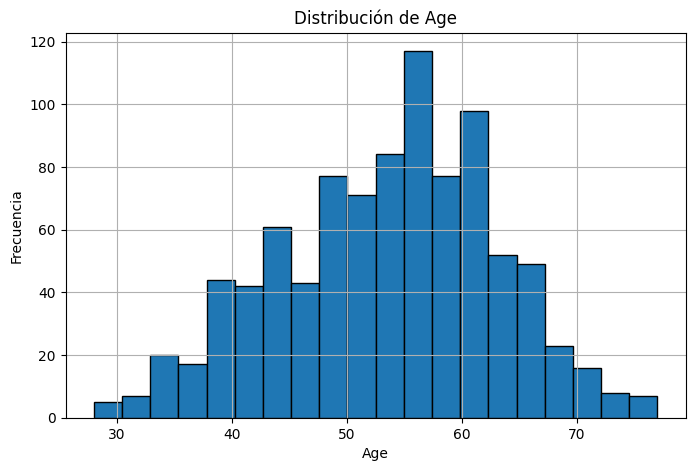

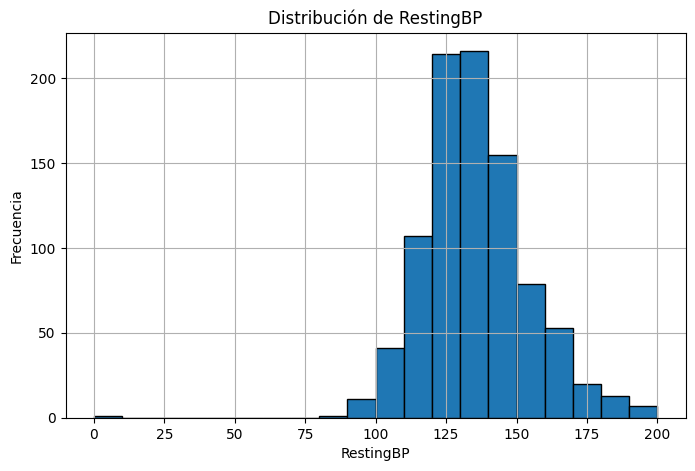

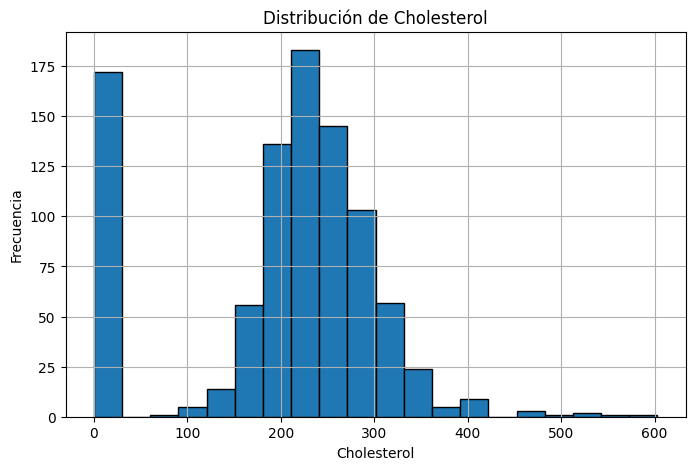

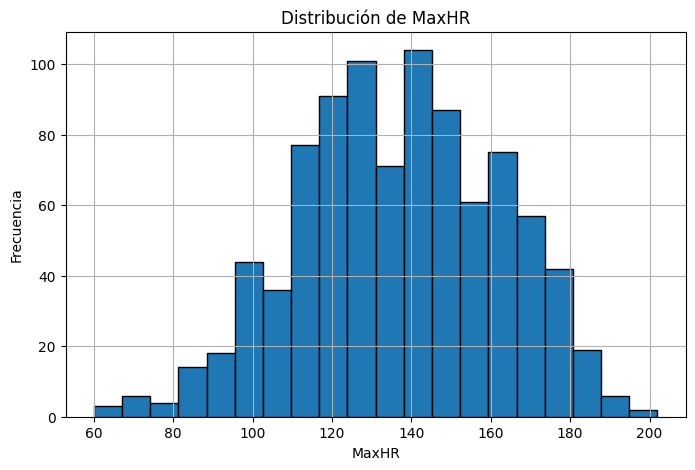

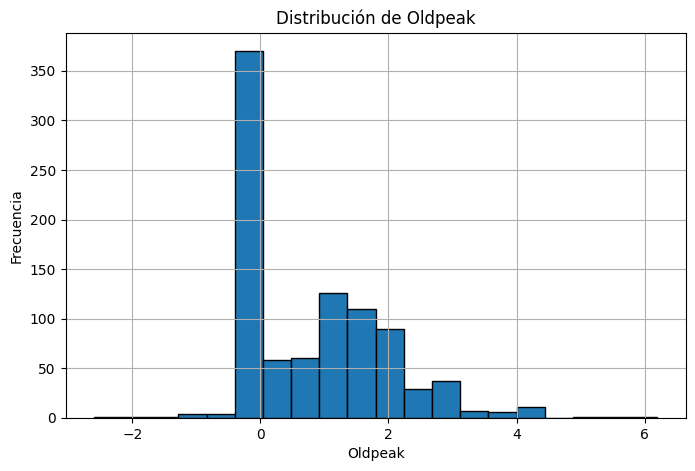

In [44]:
for col in ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']:
    fig,ax=plt.subplots(); ax.hist(df[col].dropna(),bins=20,edgecolor='black'); ax.set_title(f'Distribución de {col}'); ax.set_xlabel(col); ax.set_ylabel('Frecuencia'); plt.show()

,prevalencia,cantidad
Sex,,
M,0.6317,725
F,0.2591,193


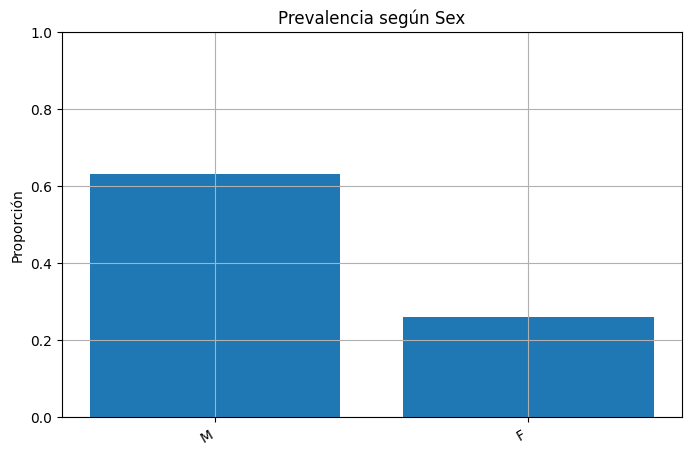

,prevalencia,cantidad
ChestPainType,,
ASY,0.7903,496
TA,0.4348,46
NAP,0.3547,203
ATA,0.1387,173


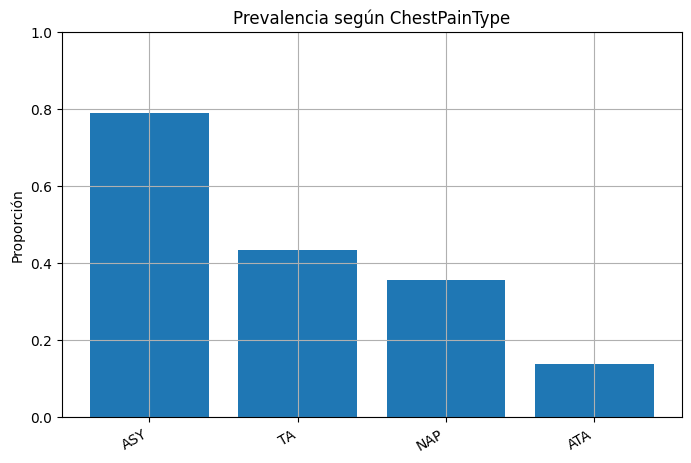

,prevalencia,cantidad
RestingECG,,
ST,0.6573,178
LVH,0.5638,188
Normal,0.5163,552


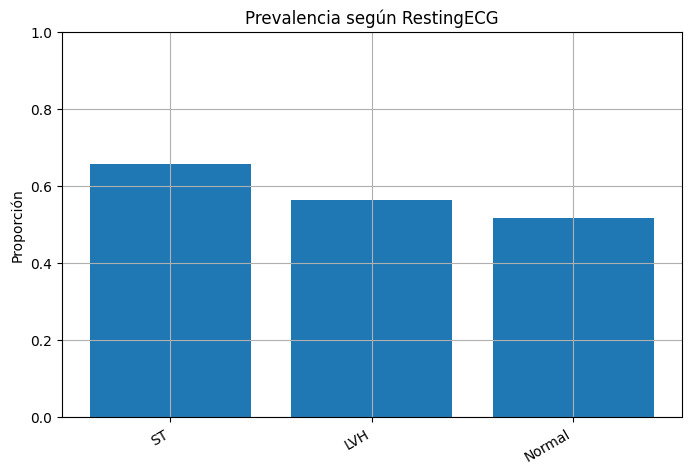

,prevalencia,cantidad
ExerciseAngina,,
Y,0.8518,371
N,0.3510,547


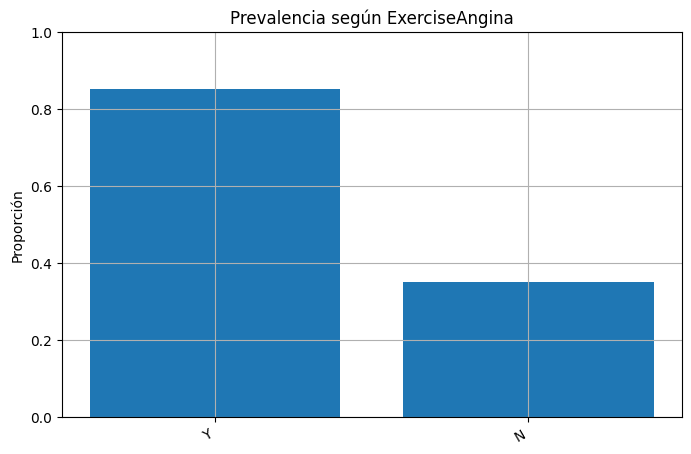

,prevalencia,cantidad
ST_Slope,,
Flat,0.8283,460
Down,0.7778,63
Up,0.1975,395


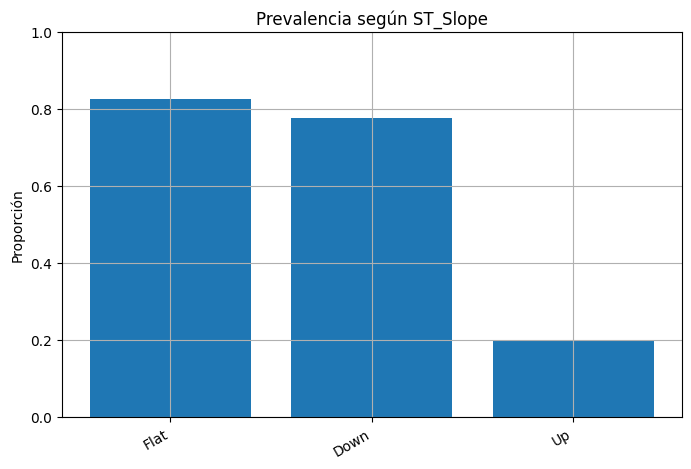

In [45]:
cats=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
for col in cats:
    prev=df.groupby(col,observed=False).HeartDisease.agg(prevalencia='mean',cantidad='count').sort_values('prevalencia',ascending=False)
    display(prev.round(4)); fig,ax=plt.subplots(); ax.bar(prev.index.astype(str),prev.prevalencia); ax.set_ylim(0,1); ax.set_title(f'Prevalencia según {col}'); ax.set_ylabel('Proporción'); plt.xticks(rotation=30,ha='right'); plt.show()

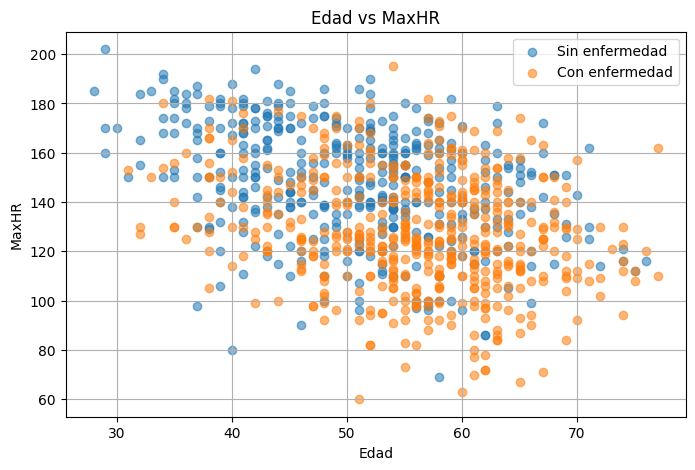

In [46]:
fig,ax=plt.subplots()
for v,label in [(0,'Sin enfermedad'),(1,'Con enfermedad')]:
    s=df[df.HeartDisease==v]; ax.scatter(s.Age,s.MaxHR,alpha=.55,label=label)
ax.set_title('Edad vs MaxHR'); ax.set_xlabel('Edad'); ax.set_ylabel('MaxHR'); ax.legend(); plt.show()

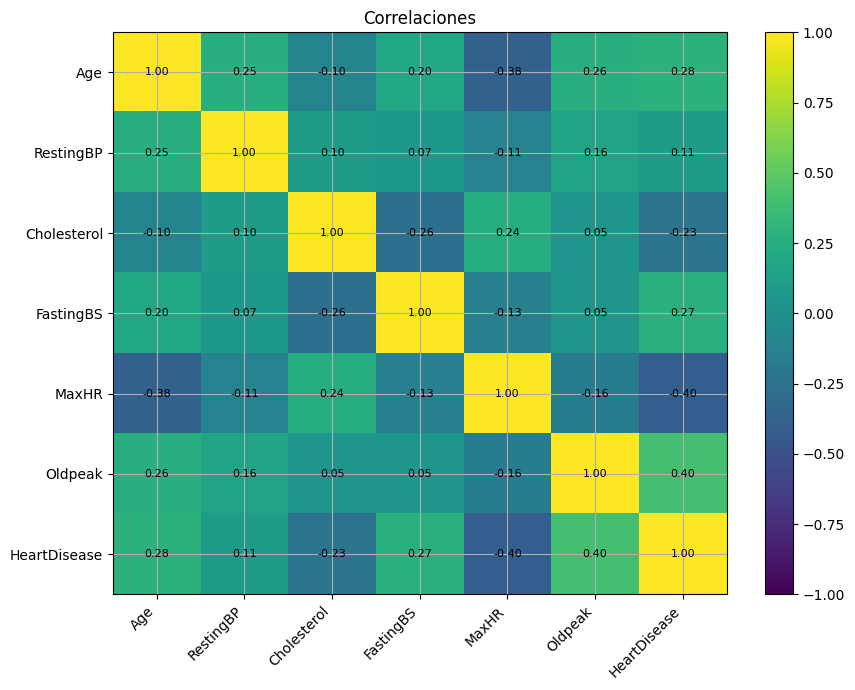

In [47]:
num=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']; corr=df[num].corr()
fig,ax=plt.subplots(figsize=(9,7)); im=ax.imshow(corr,vmin=-1,vmax=1,aspect='auto'); ax.set_xticks(range(len(num))); ax.set_yticks(range(len(num))); ax.set_xticklabels(num,rotation=45,ha='right'); ax.set_yticklabels(num)
for i in range(len(num)):
    for j in range(len(num)): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax); ax.set_title('Correlaciones'); plt.tight_layout(); plt.show()

### Síntesis EDA

El objetivo no está gravemente desbalanceado. Hay señales útiles en variables clínicas y categóricas, además de valores inválidos codificados como cero. Las asociaciones no implican causalidad.

## 7. Limpieza e ingeniería de atributos

In [48]:
def prepare_features(data):
    d=data.copy(); d['RestingBP']=d.RestingBP.replace(0,np.nan); d['Cholesterol']=d.Cholesterol.replace(0,np.nan)
    d['AgeGroup']=pd.cut(d.Age,[0,39,49,59,69,np.inf],labels=['<40','40-49','50-59','60-69','70+'])
    d['HR_Age_Ratio']=d.MaxHR/d.Age; d['Cholesterol_Age_Ratio']=d.Cholesterol/d.Age
    return d
m=prepare_features(df); X=m.drop(columns='HeartDisease'); y=m.HeartDisease.astype(int)
X.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,AgeGroup,HR_Age_Ratio,Cholesterol_Age_Ratio
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,40-49,4.300000,7.225000
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,40-49,3.183673,3.673469
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,<40,2.648649,7.648649
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,40-49,2.250000,4.458333
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,50-59,2.259259,3.611111


`AgeGroup`, `HR_Age_Ratio` y `Cholesterol_Age_Ratio` buscan representar relaciones no lineales o relativas. Su utilidad se valida empíricamente.

## 8. Train/test y preprocesamiento

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=SEED)
print(X_train.shape,X_test.shape,round(y_train.mean(),4),round(y_test.mean(),4))

(734, 14) (184, 14) 0.5531 0.5543


In [50]:
num_features=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HR_Age_Ratio','Cholesterol_Age_Ratio']
cat_features=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope','AgeGroup']
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
preprocessor=ColumnTransformer([('num',num_pipe,num_features),('cat',cat_pipe,cat_features)],verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'RestingBP', 'Cholesterol',
                                  'FastingBS', 'MaxHR', 'Oldpeak',
                                  'HR_Age_Ratio', 'Cholesterol_Age_Ratio']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'ChestPainType', 'RestingECG',
                                  'ExerciseAngina', 'ST_Slope', 'AgeGroup'])],
                  verbose_feature_names_out=False)

## 9. Comparación de modelos con validación cruzada

In [51]:
models={
'Regresión logística':LogisticRegression(max_iter=2000,class_weight='balanced',random_state=SEED),
'Árbol de decisión':DecisionTreeClassifier(class_weight='balanced',random_state=SEED),
'Random Forest':RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=SEED,n_jobs=-1),
'XGBoost':XGBClassifier(n_estimators=300,learning_rate=.05,max_depth=4,subsample=.9,colsample_bytree=.9,objective='binary:logistic',eval_metric='logloss',random_state=SEED,n_jobs=-1)}
cv=StratifiedKFold(5,shuffle=True,random_state=SEED); scoring={'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'}
rows=[]
for name,model in models.items():
    pipe=Pipeline([('preprocessor',clone(preprocessor)),('model',clone(model))])
    s=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,return_train_score=True,n_jobs=-1)
    rows.append({'Modelo':name,'ROC-AUC CV':s['test_roc_auc'].mean(),'ROC-AUC std':s['test_roc_auc'].std(),'Recall CV':s['test_recall'].mean(),'Precision CV':s['test_precision'].mean(),'F1 CV':s['test_f1'].mean(),'Accuracy CV':s['test_accuracy'].mean(),'ROC-AUC train':s['train_roc_auc'].mean(),'Brecha':s['train_roc_auc'].mean()-s['test_roc_auc'].mean()})
cv_results=pd.DataFrame(rows).sort_values('ROC-AUC CV',ascending=False).reset_index(drop=True); cv_results.round(4)

,Modelo,ROC-AUC CV,ROC-AUC std,Recall CV,Precision CV,F1 CV,Accuracy CV,ROC-AUC train,Brecha
0,Random Forest,0.9234,0.0255,0.8868,0.8476,0.8656,0.8474,1.0000,0.0766
1,XGBoost,0.9229,0.0274,0.8991,0.8684,0.8830,0.8678,0.9999,0.0770
2,Regresión logística,0.9211,0.0327,0.8424,0.8628,0.8511,0.8366,0.9305,0.0094
3,Árbol de decisión,0.7879,0.0451,0.8227,0.8075,0.8141,0.7915,1.0000,0.2121


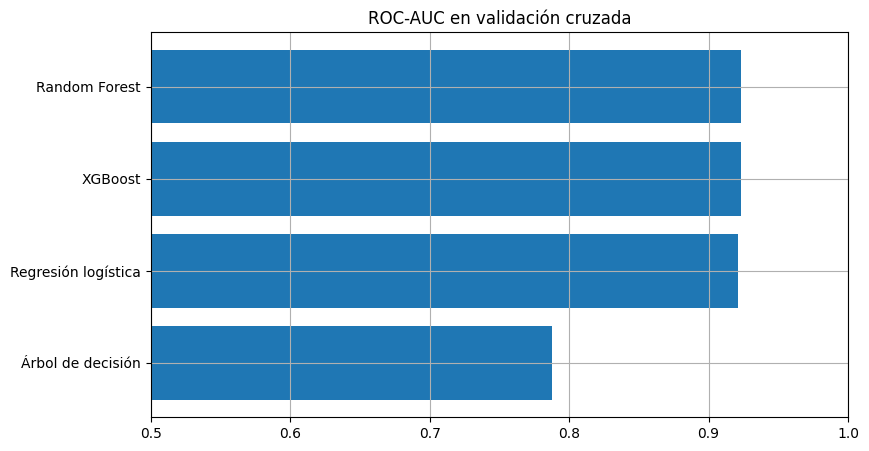

In [52]:
o=cv_results.sort_values('ROC-AUC CV'); fig,ax=plt.subplots(figsize=(9,5)); ax.barh(o.Modelo,o['ROC-AUC CV']); ax.set_xlim(.5,1); ax.set_title('ROC-AUC en validación cruzada'); plt.show()

## 10. Optimización de hiperparámetros

In [53]:
rf_pipe=Pipeline([('preprocessor',clone(preprocessor)),('model',RandomForestClassifier(class_weight='balanced',random_state=SEED,n_jobs=-1))])
rf_grid={'model__n_estimators':[200,400],'model__max_depth':[None,6,10],'model__min_samples_split':[2,5],'model__min_samples_leaf':[1,2],'model__max_features':['sqrt']}
rf_search=GridSearchCV(rf_pipe,rf_grid,scoring='roc_auc',cv=cv,n_jobs=-1,refit=True,return_train_score=True); rf_search.fit(X_train,y_train)
print(round(rf_search.best_score_,4)); print(rf_search.best_params_)

0.9267
{'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [54]:
xgb_pipe=Pipeline([('preprocessor',clone(preprocessor)),('model',XGBClassifier(objective='binary:logistic',eval_metric='logloss',random_state=SEED,n_jobs=-1))])
xgb_params={'model__n_estimators':[150,250,350,500],'model__learning_rate':[.02,.05,.08,.12],'model__max_depth':[2,3,4,5],'model__min_child_weight':[1,3,5],'model__subsample':[.75,.9,1.0],'model__colsample_bytree':[.75,.9,1.0],'model__reg_alpha':[0,.01,.1],'model__reg_lambda':[1,2,5]}
xgb_search=RandomizedSearchCV(xgb_pipe,xgb_params,n_iter=15,scoring='roc_auc',cv=cv,random_state=SEED,n_jobs=-1,refit=True,return_train_score=True); xgb_search.fit(X_train,y_train)
print(round(xgb_search.best_score_,4)); print(xgb_search.best_params_)

0.9318
{'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 250, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.75}


## 11. Selección y evaluación final

In [55]:
candidates={'Random Forest optimizado':rf_search,'XGBoost optimizado':xgb_search}
selection=pd.DataFrame([{'Modelo':n,'ROC-AUC CV':s.best_score_,'ROC-AUC train':s.cv_results_['mean_train_score'][s.best_index_]} for n,s in candidates.items()]); selection['Brecha']=selection['ROC-AUC train']-selection['ROC-AUC CV']; selection=selection.sort_values('ROC-AUC CV',ascending=False).reset_index(drop=True); selection.round(4)

,Modelo,ROC-AUC CV,ROC-AUC train,Brecha
0,XGBoost optimizado,0.9318,0.9651,0.0332
1,Random Forest optimizado,0.9267,0.9849,0.0581


In [56]:
best_name=selection.loc[0,'Modelo']; best_pipeline=candidates[best_name].best_estimator_; print('Modelo:',best_name)
y_pred=best_pipeline.predict(X_test); y_prob=best_pipeline.predict_proba(X_test)[:,1]
metrics=pd.Series({'ROC-AUC':roc_auc_score(y_test,y_prob),'Accuracy':accuracy_score(y_test,y_pred),'Precision':precision_score(y_test,y_pred),'Recall':recall_score(y_test,y_pred),'F1':f1_score(y_test,y_pred)},name='Test'); metrics.round(4)

Modelo: XGBoost optimizado


,Test
ROC-AUC,0.9269
Accuracy,0.8859
Precision,0.8716
Recall,0.9314
F1,0.9005


In [57]:
print(classification_report(y_test,y_pred,target_names=['Sin enfermedad','Con enfermedad'],digits=4))

                precision    recall  f1-score   support

Sin enfermedad     0.9067    0.8293    0.8662        82
Con enfermedad     0.8716    0.9314    0.9005       102

      accuracy                         0.8859       184
     macro avg     0.8891    0.8803    0.8834       184
  weighted avg     0.8872    0.8859    0.8852       184



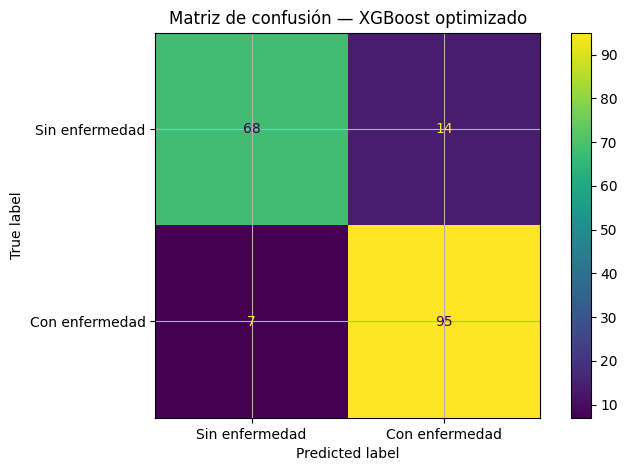

In [58]:
fig,ax=plt.subplots(); ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=['Sin enfermedad','Con enfermedad'],ax=ax); ax.set_title(f'Matriz de confusión — {best_name}'); plt.show()

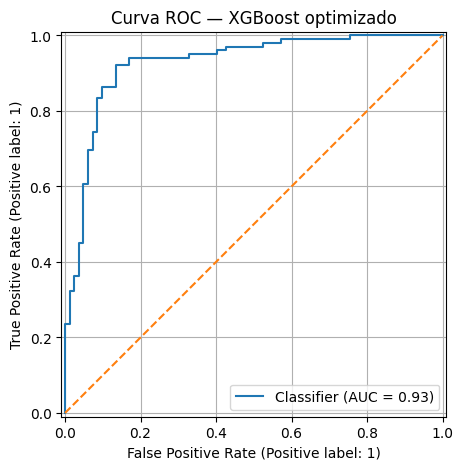

In [59]:
fig,ax=plt.subplots(); RocCurveDisplay.from_predictions(y_test,y_prob,ax=ax); ax.plot([0,1],[0,1],linestyle='--'); ax.set_title(f'Curva ROC — {best_name}'); plt.show()

## 12. Análisis de umbral

In [60]:
rows=[]
for t in np.arange(.20,.81,.05):
    p=(y_prob>=t).astype(int); cm=confusion_matrix(y_test,p)
    rows.append({'Umbral':round(float(t),2),'Precision':precision_score(y_test,p,zero_division=0),'Recall':recall_score(y_test,p,zero_division=0),'F1':f1_score(y_test,p,zero_division=0),'Falsos negativos':int(cm[1,0])})
thresholds=pd.DataFrame(rows); thresholds.round(4)

,Umbral,Precision,Recall,F1,Falsos negativos
0,0.20,0.7638,0.9510,0.8472,5
1,0.25,0.7805,0.9412,0.8533,6
2,0.30,0.8136,0.9412,0.8727,6
3,0.35,0.8348,0.9412,0.8848,6
4,0.40,0.8421,0.9412,0.8889,6
5,0.45,0.8727,0.9412,0.9057,6
6,0.50,0.8716,0.9314,0.9005,7
7,0.55,0.8922,0.8922,0.8922,11
8,0.60,0.8980,0.8627,0.8800,14
9,0.65,0.9140,0.8333,0.8718,17


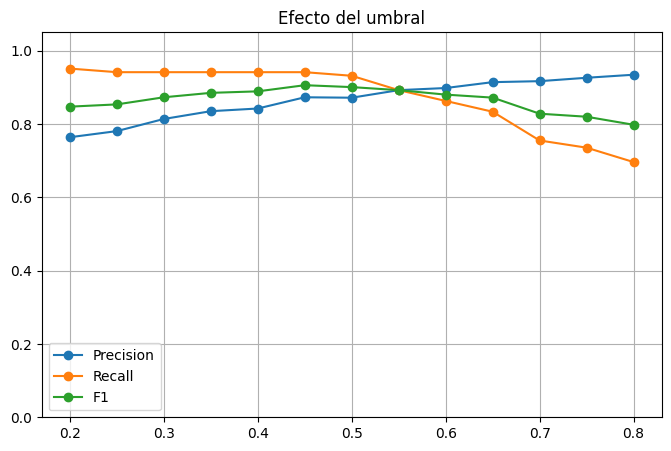

In [61]:
fig,ax=plt.subplots()
for metric in ['Precision','Recall','F1']: ax.plot(thresholds.Umbral,thresholds[metric],marker='o',label=metric)
ax.set_ylim(0,1.05); ax.set_title('Efecto del umbral'); ax.legend(); plt.show()

Un umbral menor suele aumentar recall y reducir falsos negativos, pero genera más falsos positivos. La decisión real requiere costos clínicos y operativos.

## 13. Explicabilidad con SHAP

In [62]:
prep = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["model"]

# Obtener nombres transformados
names = prep.get_feature_names_out()

# Limpiar caracteres incompatibles con XGBoost
safe_names = (
    pd.Index(names)
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "menor_", regex=False)
    .str.replace(">", "mayor_", regex=False)
    .str.replace(" ", "_", regex=False)
)

# Transformar datos
Xtr = pd.DataFrame(
    prep.transform(X_train),
    columns=safe_names,
    index=X_train.index
)

Xte = pd.DataFrame(
    prep.transform(X_test),
    columns=safe_names,
    index=X_test.index
)

sample = Xte.iloc[:min(150, len(Xte))]

# Explicador SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(sample)

print("Variables transformadas:", len(safe_names))
print("Forma SHAP:", shap_values.values.shape)

Variables transformadas: 27
Forma SHAP: (150, 27)


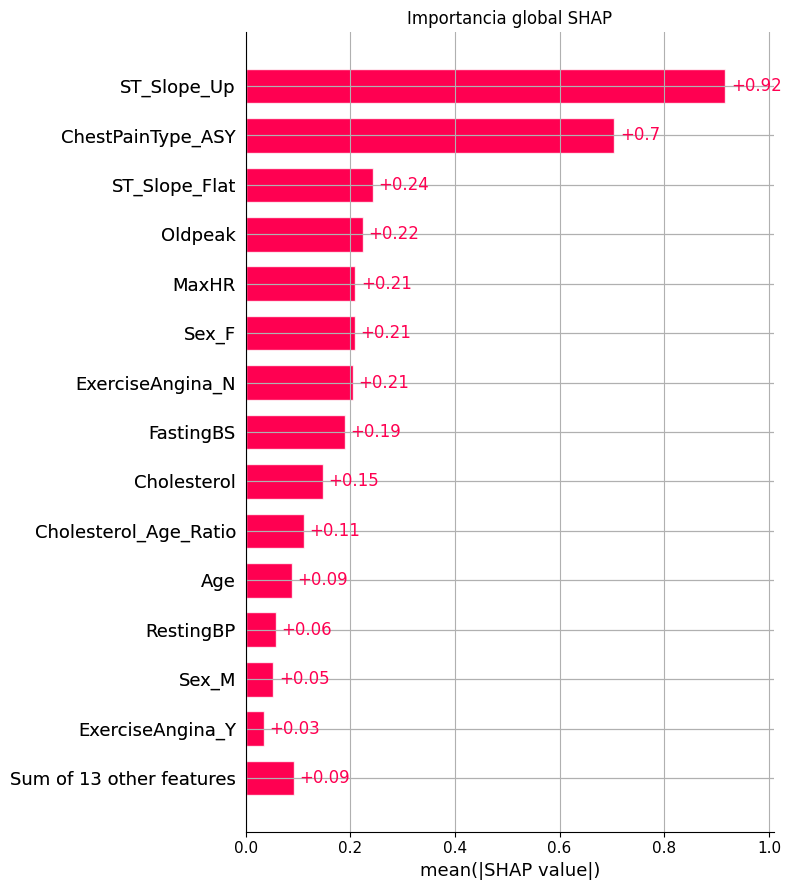

In [63]:
shap.plots.bar(shap_values,max_display=15,show=False); plt.title('Importancia global SHAP'); plt.tight_layout(); plt.show()

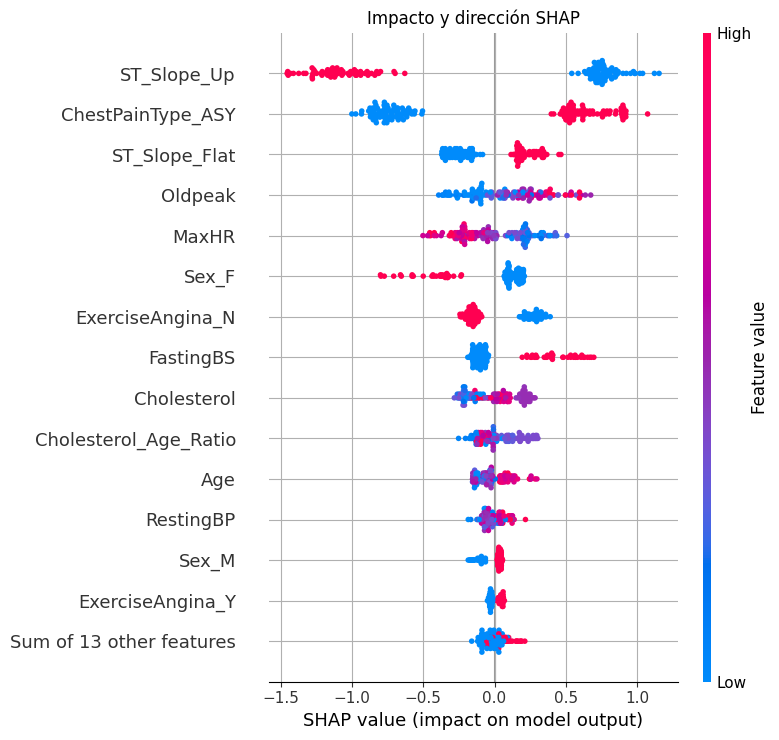

In [64]:
shap.plots.beeswarm(shap_values,max_display=15,show=False); plt.title('Impacto y dirección SHAP'); plt.tight_layout(); plt.show()

Índice: 356 | Real: 1 | Probabilidad: 0.949


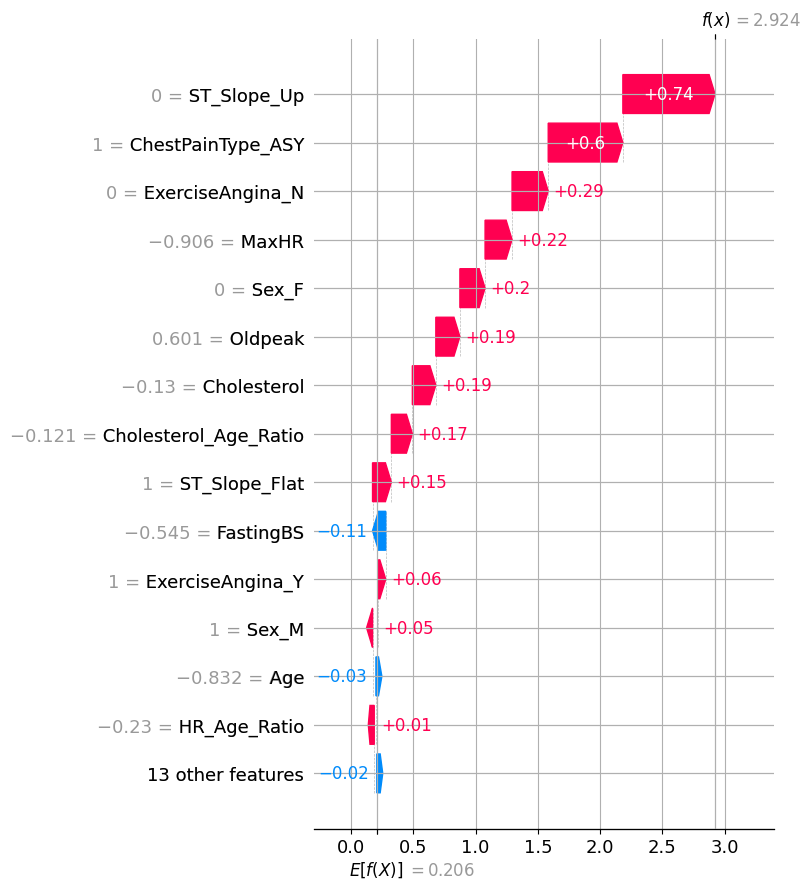

In [65]:
pos=0; idx=sample.index[pos]; print('Índice:',idx,'| Real:',int(y_test.loc[idx]),'| Probabilidad:',round(float(best_pipeline.predict_proba(X_test.loc[[idx]])[:,1][0]),4)); shap.plots.waterfall(shap_values[pos],max_display=15,show=False); plt.tight_layout(); plt.show()

SHAP explica el comportamiento del modelo, no causalidad. Valores positivos empujan hacia enfermedad y negativos hacia ausencia.

## 14. Importancia por permutación

In [66]:
perm=permutation_importance(best_pipeline,X_test,y_test,scoring='roc_auc',n_repeats=10,random_state=SEED,n_jobs=-1)
perm_df=pd.DataFrame({'Variable':X_test.columns,'Importancia media':perm.importances_mean,'Desvío':perm.importances_std}).sort_values('Importancia media',ascending=False); perm_df.round(4)

,Variable,Importancia media,Desvío
10,ST_Slope,0.0937,0.0190
2,ChestPainType,0.0250,0.0084
1,Sex,0.0165,0.0047
9,Oldpeak,0.0137,0.0053
5,FastingBS,0.0083,0.0032
8,ExerciseAngina,0.0069,0.0027
3,RestingBP,0.0036,0.0016
4,Cholesterol,0.0034,0.0024
0,Age,0.0028,0.0015
6,RestingECG,0.0016,0.0009


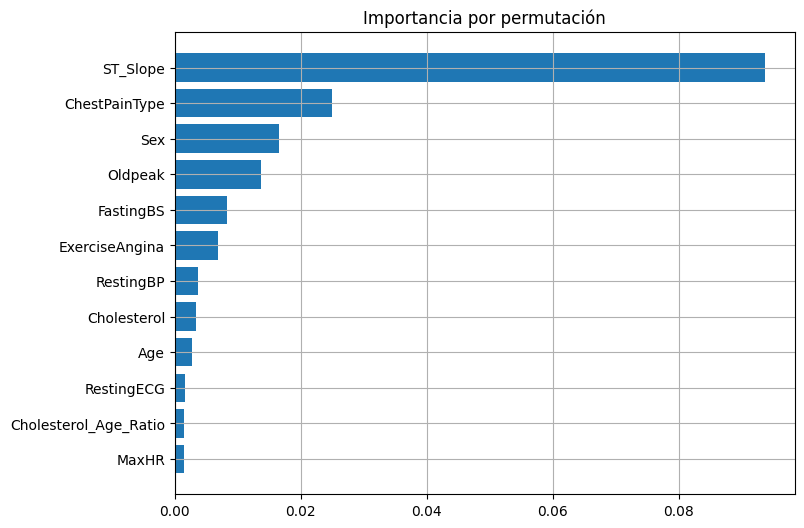

In [67]:
top=perm_df.head(12).sort_values('Importancia media'); fig,ax=plt.subplots(figsize=(8,6)); ax.barh(top.Variable,top['Importancia media']); ax.set_title('Importancia por permutación'); plt.show()

## 15. Resumen automático

In [68]:
print('Modelo:',best_name)
print('ROC-AUC CV:',round(float(selection.loc[0,'ROC-AUC CV']),4))
for k,v in metrics.items(): print(f'{k}: {v:.4f}')

Modelo: XGBoost optimizado
ROC-AUC CV: 0.9318
ROC-AUC: 0.9269
Accuracy: 0.8859
Precision: 0.8716
Recall: 0.9314
F1: 0.9005


## 16. Conclusiones y limitaciones

El notebook entrega un pipeline completo. La conclusión final debe mencionar el modelo seleccionado, ROC-AUC, recall, precision, F1, falsos negativos, brecha de sobreajuste y variables principales según SHAP.

**Limitaciones:** muestra pequeña, procedencia y muestreo limitados, nulos codificados como cero, ausencia de validación externa, riesgo de sesgo y falta de calibración clínica. El modelo puede apoyar priorización, pero no decidir de forma autónoma.

## 17. Reproducibilidad

1. Instalar `requirements.txt`.
2. Guardar `heart.csv` junto al notebook o en `data/`.
3. Ejecutar **Restart Kernel and Run All**.
4. Verificar que no haya errores.

```text
proyecto-final-ml/
├── README.md
├── ProyectoFinal2-Martinelli.ipynb
├── requirements.txt
├── heart.csv
└── .gitignore
```

### Checklist

- [x] Problema y métrica definidos
- [x] EDA
- [x] Limpieza e ingeniería de atributos
- [x] Varios modelos
- [x] Validación cruzada
- [x] Optimización
- [x] Evaluación final
- [x] SHAP
- [x] Limitaciones y reproducibilidad